In [1]:
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

sys.path.append("..")
from enrichment_utils import (
    bh_correction_on_matrix,
    format_hue_name_disease_tissue,
    get_valid_disease_tissue_pairs,
    map_development_stage_to_age_bin,
    plot_subcluster_enrichment_by_feature,
    _configure_clustermap_layout,
)

matplotlib.rcParams["pdf.fonttype"] = 42  # Editable text in Illustrator
pd.set_option("display.max_columns", None)

In [2]:
FIGURES_DIR = "../../figures/cellxgene-2025-11-08/"
SAVE_FIGURES = True

In [3]:
enrichment_adata = sc.read_h5ad("enrichment-ref_k=50-query_k=20.h5ad")
assert enrichment_adata.obs["is_primary_data"].all()
mrvi_labeled_adata = sc.read_h5ad("../../cluster/mrvi.leiden.labeled.h5ad")
subcluster_idx_to_full_name = dict(
    zip(mrvi_labeled_adata.obs["subcluster_idx"], mrvi_labeled_adata.obs["subcluster"])
)
del mrvi_labeled_adata

# Preprocess data

### Disease-tissue pairs

In [4]:
disease_tissue_pairs_to_counts = get_valid_disease_tissue_pairs(
    enrichment_adata,
    min_cumulative_disease_counts=1250,
    min_tissue_counts=1_000,
    diseases_to_exclude=["normal"],
)
valid_disease_tissue_pairs = [f"{d}:{t}" for d, t in disease_tissue_pairs_to_counts.keys()]
valid_diseases = sorted(set(d.split(":")[0] for d in valid_disease_tissue_pairs))

print(f"# of valid disease:tissue pairs: {len(valid_disease_tissue_pairs)}")
for (disease, tissue), count in disease_tissue_pairs_to_counts.items():
    print(f"{disease} - {tissue}: {count}")

enrichment_adata.obs["disease_tissue"] = enrichment_adata.obs.apply(
    lambda row: f"{row['disease']}:{row['tissue_general']}", axis=1
)

# of valid disease:tissue pairs: 22
COVID-19 - blood: 58612
COVID-19 - lung: 5140
cytomegalovirus infection - blood: 31322
systemic lupus erythematosus - blood: 21047
malignant ovarian serous tumor - abdomen: 6084
malignant ovarian serous tumor - omentum: 1926
B-cell non-Hodgkin lymphoma - bone marrow: 3271
B-cell non-Hodgkin lymphoma - lymph node: 2285
lung adenocarcinoma - lung: 4411
glioblastoma - brain: 3483
juvenile dermatomyositis - blood: 3678
influenza - blood: 2442
respiratory system disorder - blood: 2067
rheumatoid arthritis - blood: 1910
hematologic disorder - blood: 1842
open-angle glaucoma - blood: 1764
clear cell renal carcinoma - blood: 1446
primary sclerosing cholangitis - liver: 1617
pulmonary fibrosis - lung: 1496
interstitial lung disease - lung: 1448
myelodysplastic syndrome - blood: 1425
atherosclerosis - vasculature: 1337


In [5]:
disease_to_category = {
    "B-cell non-Hodgkin lymphoma": "neoplastic disease",
    "COVID-19": "infectious disease",
    "atherosclerosis": "organ system disease",
    "clear cell renal carcinoma": "neoplastic disease",
    "glioblastoma": "neoplastic disease",
    "hematologic disorder": "organ system disease",
    "influenza": "infectious disease",
    "juvenile dermatomyositis": "autoimmune disease",
    "lung adenocarcinoma": "neoplastic disease",
    "malignant ovarian serous tumor": "neoplastic disease",
    "myelodysplastic syndrome": "neoplastic disease",
    "post-COVID-19 disorder": "infectious disease",
    "primary sclerosing cholangitis": "autoimmune disease",
    "respiratory system disorder": "organ system disease",
    "rheumatoid arthritis": "autoimmune disease",
    "systemic lupus erythematosus": "autoimmune disease",
    "cytomegalovirus infection": "infectious disease",
    "interstitial lung disease": "organ system disease",
    "open-angle glaucoma": "organ system disease",
    "pulmonary fibrosis": "organ system disease",
}

assert set(valid_diseases).issubset(set(disease_to_category.keys()))
enrichment_adata.obs["disease_category"] = enrichment_adata.obs["disease"].map(disease_to_category)

### Age

In [6]:
enrichment_adata.obs["age_bin"] = enrichment_adata.obs["development_stage"].apply(
    map_development_stage_to_age_bin
)
enrichment_adata.obs["age_bin"].value_counts()

age_bin
40-59      129869
20-39      125640
60-79      105899
Unknown     32669
80+         11539
3-19         8615
0-2          5141
embryo       2975
Name: count, dtype: int64

# Plot

### Individual

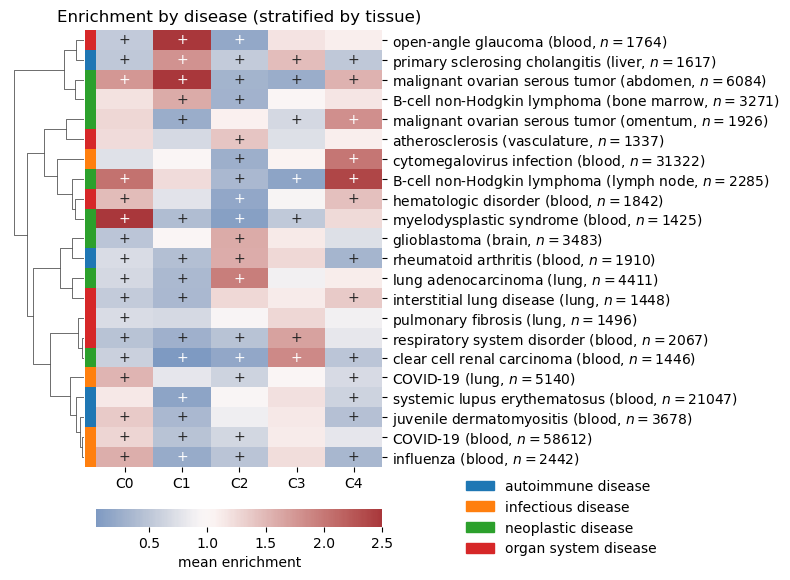

In [7]:
# By disease and tissue
cg = plot_subcluster_enrichment_by_feature(
    enrichment_adata,
    subcluster_idx_to_full_name,
    "disease_tissue",
    valid_features=valid_disease_tissue_pairs,
    format_hue_name=format_hue_name_disease_tissue,
    col_cluster=False,
    feature_category_colname="disease_category",
    figsize=(8, 6),
    cbar_y_offset=0.1,
    vmax=2.5,
)
cg.ax_heatmap.set_title("Enrichment by disease (stratified by tissue)")

if SAVE_FIGURES:
    os.makedirs(FIGURES_DIR, exist_ok=True)
    cg.figure.savefig(
        os.path.join(FIGURES_DIR, "heatmap.by_disease_and_tissue.pdf"), bbox_inches="tight"
    )
plt.show()

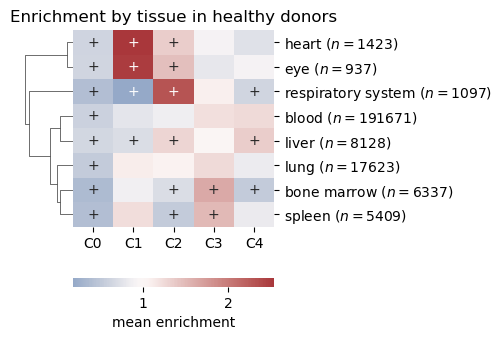

In [21]:
# By tissue in healthy donors
cg = plot_subcluster_enrichment_by_feature(
    enrichment_adata[enrichment_adata.obs["disease"] == "normal"],
    subcluster_idx_to_full_name,
    "tissue_general",
    min_cells_per_feature=750,
    figsize=(5, 3),
    col_cluster=False,
)
cg.ax_heatmap.set_title("Enrichment by tissue in healthy donors")

if SAVE_FIGURES:
    cg.figure.savefig(
        os.path.join(FIGURES_DIR, "heatmap.by_tissue_in_healthy_donors.pdf"), bbox_inches="tight"
    )
plt.show()

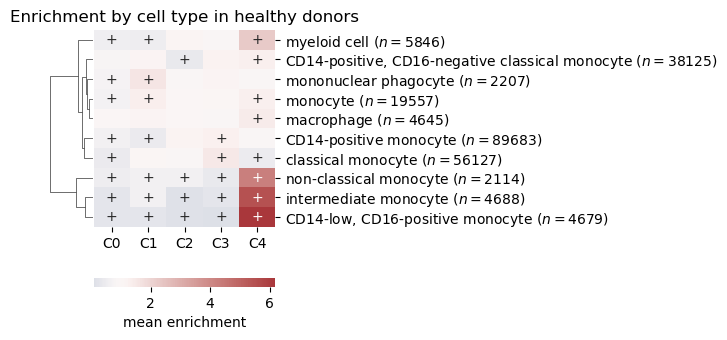

In [12]:
# By cell type in healthy donors
cg = plot_subcluster_enrichment_by_feature(
    enrichment_adata[enrichment_adata.obs["disease"] == "normal"],
    subcluster_idx_to_full_name,
    "cell_type",
    min_cells_per_feature=2_000,
    excluded_features=["unknown"],
    figsize=(7, 3),
    col_cluster=False,
)
cg.ax_heatmap.set_title("Enrichment by cell type in healthy donors")

if SAVE_FIGURES:
    cg.figure.savefig(
        os.path.join(FIGURES_DIR, "heatmap.by_cell_type_in_healthy_donors.pdf"), bbox_inches="tight"
    )
plt.show()

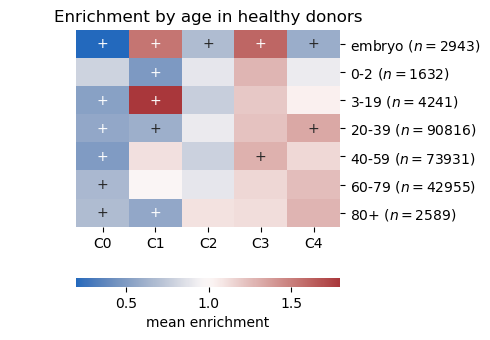

In [22]:
# By age in healthy donors
cg = plot_subcluster_enrichment_by_feature(
    enrichment_adata[enrichment_adata.obs["disease"] == "normal"],
    subcluster_idx_to_full_name,
    "age_bin",
    valid_features=["embryo", "0-2", "3-19", "20-39", "40-59", "60-79", "80+"],
    figsize=(5, 3),
    row_cluster=False,
    col_cluster=False,
)
cg.ax_heatmap.set_title("Enrichment by age in healthy donors")

if SAVE_FIGURES:
    cg.figure.savefig(
        os.path.join(FIGURES_DIR, "heatmap.by_age_in_healthy_donors.pdf"), bbox_inches="tight"
    )
plt.show()

# Combined

In [23]:
disease_enr_df, disease_pval_df = plot_subcluster_enrichment_by_feature(
    enrichment_adata,
    subcluster_idx_to_full_name,
    "disease_tissue",
    valid_features=valid_disease_tissue_pairs,
    format_hue_name=format_hue_name_disease_tissue,
    feature_category_colname="disease_category",
    return_df_only=True,
)

tissue_enr_df, tissue_pval_df = plot_subcluster_enrichment_by_feature(
    enrichment_adata[enrichment_adata.obs["disease"] == "normal"],
    subcluster_idx_to_full_name,
    "tissue_general",
    min_cells_per_feature=750,
    return_df_only=True,
)

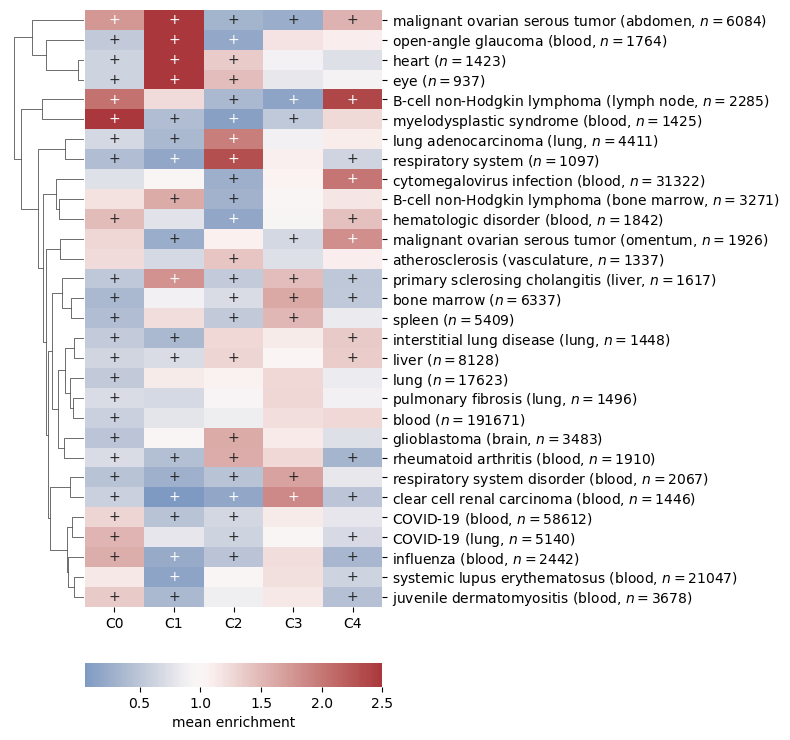

In [25]:
combined_enr_df = pd.concat([disease_enr_df, tissue_enr_df], axis=0)
combined_pval_df = pd.concat([disease_pval_df, tissue_pval_df], axis=0)
combined_padj = bh_correction_on_matrix(combined_pval_df.values, alpha=0.05)
combined_annots = np.vectorize(lambda p: "+" if p < 0.05 else "")(combined_padj)
combined_annots_df = pd.DataFrame(
    combined_annots, index=combined_enr_df.index, columns=combined_enr_df.columns
)

cg = sns.clustermap(
    combined_enr_df,
    annot=combined_annots_df,
    fmt="",
    cmap="vlag",
    center=1.0,
    cbar_pos=(0.25, -0.1, 0.5, 0.03),
    cbar_kws={"label": "mean enrichment", "orientation": "horizontal"},
    figsize=(8, 8),
    vmax=2.5,
    col_cluster=False,
)

_configure_clustermap_layout(cg, cbar_y_offset=0.1)

if SAVE_FIGURES:
    cg.figure.savefig(
        os.path.join(FIGURES_DIR, "heatmap.combined.pdf"),
        bbox_inches="tight",
    )
plt.show()